# **Esame del 3 febbraio 2025**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10)**

Si consideri la matrice


$$\mathbf{A}=\left[\begin{array}{rrrrrrr}
7 & -3 & 1 &  &  & & \\
-3 & 7 & -3 & 1 &  & & \\
1 & -3 & 7 & -3 & 1 & & \\
& 1 & -3 & 7 & -3 & 1 &\\
& & 1 & -3 & 7 & -3 & 1 \\
& & & 1 & -3 & 7 & -3  \\
& & & & 1 & -3 & 7  \\
\end{array}\right], $$

#### **(1a) (3 punti) [T]**

Illustrare un generico metodo iterativo basato sulla matrice di
iterazione $B$ per la risoluzione di un sistema lineare. Enunciare la condizione necessaria e sufficiente di convergenza per tale metodo.


Una forma generale per i metodi iterativi è data dall'espressione seguente
\begin{gather*}
    \mathbf{x}^{k+1} = B \mathbf{x}^k + \mathbf{g},
\end{gather*}
dove $B\in\mathbb{R}^{n \times n}$ è detta matrice di iterazione, che
generalmente può dipendere da $A$, e $\mathbf{g}$ un vettore che viene costruito
    partendo da $A$ e $\mathbf{b}$. Il metodo è consistente se 
    \begin{gather*}
        \mathbf{x} = B \mathbf{x} + \mathbf{g},
    \end{gather*}
 e la condizione necessaria e sufficiente per la convergenza è
  \begin{gather*}
        \rho(B) < 1,
    \end{gather*}
 dove $\rho(\cdot)$ indica il raggio spettrale di una matrice.

#### **(1b) (3 punti) [T+P]**

Determinare la forma della matrice $B$ nel caso dei metodi di Jacobi e Gauss-Seidel. Per entrambi, verificare la condizione necessaria e sufficiente enunciata al punto precedente. Cosa si osserva? *Suggerimento: utilizzare scipy.linalg.eigvals*

In [2]:
# importazione pacchetti
import scipy.linalg
import numpy as np
from functions import *
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

##### **Soluzione.** 

Nel caso del metodo di Jacobi la costruzione del metodo si basa sullo splitting della matrice $A$ nella somma $D-(D-A)$ dove $D$ è una matrice diagonale con $d_{ii}=a_{ii}$. Quindi $B=D^{-1}(D-A)$.
Nel caso del metodo di Gauss Seidel si usa lo splitting $A=T-(T-A)$ dove $T$ è la parte triangolare inferiore di $A$, per cui $B=T^{-1}(T-A)$. Nel nostro caso possiamo costruire la matrice di iterazione con i comandi forniti in *functions*.

In [3]:
n = 7
A = - 3*np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-2), 2)
A = 7*np.diag(np.ones(n)) + A + A.T


Bj = Jacobi_Bc(A)
BGS = GS_Bc(A)

rhoj = np.max(np.abs(eigvals(Bj)))
rhoGS = np.max(np.abs(eigvals(BGS)))

print('jacobi rho', rhoj)
print('GS rho', rhoGS)

print(np.min(eigvals(A)))

jacobi rho 1.005754393215316
GS rho 0.38027526007902046
(2.904226454981305+0j)


Notiamo che il metodo di Jacobi ha raggio spettrale e non convergerà, mentre per Gauss Seidel il raggio spettrale è ampiamente $<1$. Infatti, osservando gli autovalori di $A$ posso verificare che anche il più piccolo è positivo, quindi la matrice è definita simmetrica e definita positiva e soddisfa la condizione sufficiente per la convergenza di Gauss Seidel.

#### **(1b) (4 punti) [P]**  

Calcolare il termine noto $\mathbf{b}$ tale per cui la soluzione esatta del sistema \`e $x_{e} = [1,1,\ldots,1]^T$. In base ai risultati del punto precedente scegliere il metodo iterativo adatto e risolvere il sistema utilizzando la function *iterative_solve* fornita in *functions*, scegliendo una tolleranza $\epsilon = 1e-6$. Calcolare l'errore relativo corrispondente a ogni iterazione e rappresentarlo in un grafico in  scala semilogaritmica. Commentare il risultato ottenuto.

##### **Soluzione.**

Consideriamo il seguente codice.

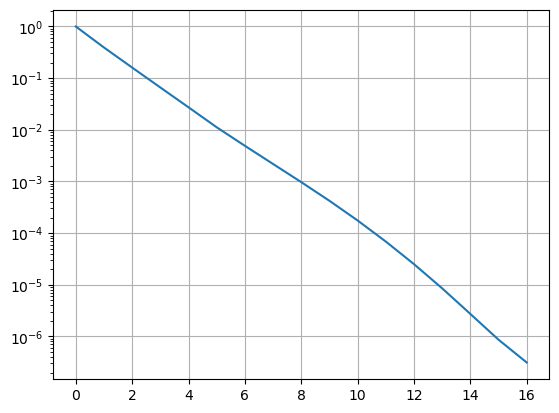

In [4]:
x0 = np.zeros(n)
xex = np.ones(n)
b = A@xex

xgs = iterative_solve(A, b, x0, method = 'GS', rtoll = 1e-6, nmax = 1000)

err = np.zeros(len(xgs))
for i in range(len(xgs)):
    err[i] = scipy.linalg.norm(xgs[i]-xex)/scipy.linalg.norm(xex)
    
plt.semilogy(range(len(xgs)), err)
plt.grid()

Osserviamo che, sebbene il criterio di arresto si basi sul criterio del residuo, a convergenza abbiamo un errore paragonabile con la tolleranza richiesta.

# **Esercizio 2 (10 punti)**


Si consideri la seguente equazione nonlineare:

$f(x) = x - 2\sin(x)$.

## **(2a) (3 punti) [T]** 
Illustrare il metodo del punto fisso per la ricerca degli zeri di equazioni non lineari. Discutere le condizioni per la sua convergenza e verificare se il metodo può essere applicato alla funzione fornita.

##### **Soluzione.** 

I metodi di punto fisso si basano sulla riscrittura del problema come
\begin{gather}
    x=\phi(x),
\end{gather}
in modo tale che $f(x)=x-\phi(x)$. La generica iterazione del metodo è quindi
\begin{gather*}
    x^{k+1}=\phi(x^k),
\end{gather*}
data una guess iniziale $x^0$.

Condizioni per la convergenza:
- $\phi:\,[a,b]\rightarrow\,[a,b]$
- $\phi\in C^1([a,b])$
- $|\phi'(x)|<1\;\forall x\,\in\,[a,b]$.

Allora $\phi$ ha un unico punto fisso $\alpha\,\in\,[a,b]$ e la sequenza $\{x^k\}$ converge ad $\alpha$ per qualsiasi scelta di $x^0\,\in\,[a,b]$. 

In alternativa, il teorema di Ostrowski fornisce un risultato locale:
 sia $\alpha$ un punto fisso della funzione $\phi$, che \`e continua e derivabile in un
    intorno di $\alpha$. Se $|\phi'(\alpha)|<1$ allora esiste un $\delta>0$ tale che la sequenza
    $\{x^k\}$ converge ad $\alpha$ per ogni $x^0$ tale che $|x^0-\alpha|<\delta$.
    
Nel nostro caso $\phi = 2\sin(x)$, $\phi'(x) = 2\cos(x)$. Richiediamo quindi che $|\cos(x)|<\frac{1}{2}$ per cui la condizione è sodisfatta per $\frac{\pi}{3} \leq x\leq \frac{2\pi}{3}$ e $-\frac{2\pi}{3} \leq x\leq -\frac{\pi}{3}$.

## **(2b) (3 punti) [P]** 
Completare la function fornita, che implementa il metodo del punto fisso. In particolare implementare la generica iterazione e il criterio d'arresto.

##### **Soluzione.** 

Implementiamo il criterio di arresto basato sull'incremento, cioè confrontiamo due successive approssimazioni della soluzione e arrestiamo il metodo quando la differenza (in modulo) è minore di una tolleranza.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def puntofisso(phi, x0, nmax=100, toll=1.e-6):

  # inizializzazione
  xvect=[]
  xold = x0

  for nit in range(nmax) :
    # calcolo il nuovo punto
    xnew= #TODO
    #salvo la soluzione
    xvect.append(xnew)

    # criterio di arresto e aggiorno
    if #TODO
        break
    else :
        xold=xnew

  return np.array(xvect)

SyntaxError: invalid syntax (1051421113.py, line 9)

In [10]:
def puntofisso(phi, x0, nmax=100, toll=1.e-6):

  # inizializzazione
  xvect=[]
  xold = x0

  for nit in range(nmax) :
    # calcolo il nuovo punto
    xnew=phi(xold)
    #carico i vettori
    xvect.append(xnew)

    # criterio di arresto e aggiorno
    if (abs(xnew-xold) < toll):
        break
    else :
        xold=xnew

  return np.array(xvect)

## **(2c) (4 punti) [P+T]** 

Stimare graficamente la/le radici della funzione fornita. Discutere per quale/quali radici il metodo di punto fisso può convergere e perché. Verificare numericamente la teoria applicando la function *puntofisso* per la ricerca delle radici, cambiando opportunamente la guess iniziale $x_0$. Commentare i risultati.

##### **Soluzione.** 

Per stimare le radici intersechiamo il grafico di $\phi(x)$ con la bisettrice. Una delle radici è ovviamente $x=0$ mentre le altre due sono simmetriche e vicine a $x=\pm 2$.

[1.68294197 1.98743653 1.82890755 1.93374764 1.86970615 1.91131618
 1.88516235 1.90198521 1.89131285 1.89814562 1.89379592 1.89657515
 1.89480351 1.89593455 1.89521316 1.89567355 1.89537985 1.89556726
 1.89544769 1.89552398 1.89547531 1.89550636 1.89548655 1.89549919
 1.89549112 1.89549627 1.89549299 1.89549508 1.89549375 1.8954946 ]
[0.19966683 0.39668559 0.77272687 1.39618059 1.96958674 1.84306271
 1.92632781 1.87492323 1.90821755 1.88722304 1.90070678 1.89214271
 1.89762206 1.89413235 1.89636147 1.89494024 1.89584747 1.89526879
 1.89563808 1.89540249 1.89555282 1.8954569  1.8955181  1.89547906
 1.89550397 1.89548808 1.89549822 1.89549175 1.89549588 1.89549324
 1.89549492 1.89549385 1.89549453]
[-1.68294197 -1.98743653 -1.82890755 -1.93374764 -1.86970615 -1.91131618
 -1.88516235 -1.90198521 -1.89131285 -1.89814562 -1.89379592 -1.89657515
 -1.89480351 -1.89593455 -1.89521316 -1.89567355 -1.89537985 -1.89556726
 -1.89544769 -1.89552398 -1.89547531 -1.89550636 -1.89548655 -1.89549919
 -

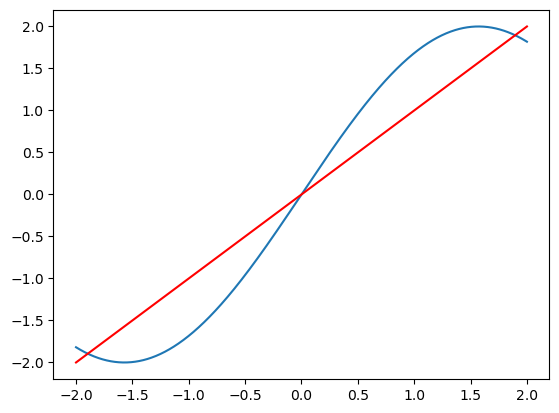

In [11]:
f = lambda x: x - 2*np.sin(x)
phi = lambda x: 2*np.sin(x)
xplot = np.linspace(-2,2,1000)
plt.plot(xplot, phi(xplot))
plt.plot(xplot,xplot,'r')

x0 = 1
xvect = puntofisso(phi, x0, nmax=100, toll=1.e-6)
print(xvect)

x0 = 0.1
xvect = puntofisso(phi, x0, nmax=100, toll=1.e-6)
print(xvect)

x0 = -1
xvect = puntofisso(phi, x0, nmax=100, toll=1.e-6)
print(xvect)

Notiamo che non riusciamo a convergere a $\alpha=0$ perché vicino a questa radice la condizione di convergenza non è soddisfatta - lo è invece per le altre due radici.

# **Esercizio 3 (10 punti)**

Si consideri il seguente problema di Cauchy:

$$
\begin{cases}
y'(t) = -2y, \quad t_0<t\leq t_\max, \\
y(t_0) = y_0,
\end{cases}
$$

con $y_0=1$, $t_0=0$, $t_\max = 10$.

#### **(3b) (1 punti) [T]** 

Verificare che $y(t) = y_0 \exp(-2t)$ è la soluzione esatta del problema.

##### **Soluzione.** 

Calcolando $y'(t) = y_0 (-2) \exp(-2t) = -2 y(t)$ verifichiamo che la soluzione fornita soddisfa l'equazione, inoltre per $t=0$ si ottiene $y(0) = y_0 \cdot \exp(0) = y_0$.

#### **(3b) (3 punti) [T]** 

Illustrare il metodo di Eulero Esplicito per la soluzione numerica di equazioni differenziali ordinarie. Discutere la convergenza del metodo e la sua *assoluta* stabilità al variare del passo $h$.

##### **Soluzione.** 

Suddividiamo l'intervallo $I =[t_0, t_\max]$ in $N$ sotto-intervalli con la stessa dimensione data da
\begin{gather*}
    h = \frac{t_\max - t_0}{N}
\end{gather*}
e definiamo gli istanti discreti in cui calcoleremo la soluzione approssimata come $t_n = t_0 + nh$. Infine chiamiamo $u_n$ l'approssimazione di $y$ all'instante $t_n$, ovvero vogliamo costruire $u_n \approx y(t_n)$.
Il metodo di Eulero Esplicito per una generica equazione differenziale nella forma

$$
\begin{cases}
y'(t) = f(t,y), \quad t_0<t\leq t_\max, \\
y(t_0) = y_0,
\end{cases}
$$

costruisce l'approssimazione come

$$
\begin{cases}
        u_{n+1} =  u_n + h f(t_n, u_n) \\
        u_0 = \overline{y}_0
\end{cases}
$$
     

#### **(3c) (3 punti) [P]** 

Applicare il metodo di Eulero Esplicito all'equazione fornita utilizzando la function *eulero_avanti* presente in *functions*, scegliendo un passo temporale che garantisca l'assoluta stabilità del metodo. Rappresentare la soluzione numerica e la soluzione esatta.

##### **Soluzione.** 

Dato che si tratta di un problema modello con $\lambda=-2$ per avere assoluta stabilità con Eulero Esplicito dobbiamo scegliere $h<\frac{2}{|\lambda|}=1$. Per ''sicurezza'' possiamo scegliere un passo pari a metà del valore limite.

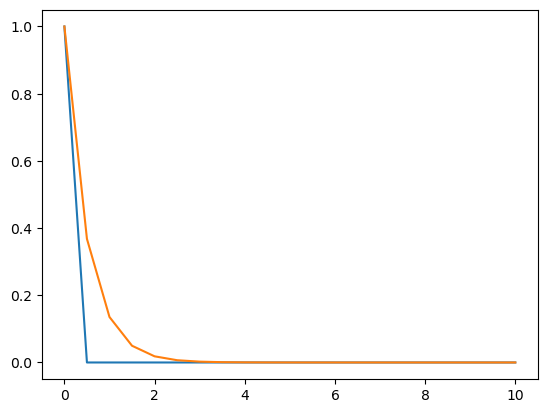

In [7]:
import numpy as np
from functions import *
import matplotlib.pyplot as plt


f = lambda t, y : -2*y
y0 = 1
t0 = 0
t_max = 10

yex = lambda t : np.exp(-2*t)

hlim = 2/(2)
h = 0.5*hlim
tEA, yEA = eulero_avanti(f, t0, t_max, [y0], h)

plt.plot(tEA,yEA)
plt.plot(tEA,yex(tEA))


#### **(3d) (3 punti) [P]**  

Risolvere il problema per i seguenti valori di $h$: $h=[0.5, 0.1, 0.05, 0.01]$. Per ognuno calcolare l'errore massimo nell'intervallo $(0,t_\max)$. Plottare l'errore in funzione di $h$ in scala logaritmica e verificare se i risultati teorici di convergenza sono confermati.

##### **Soluzione.**

Consideriamo il seguente codice

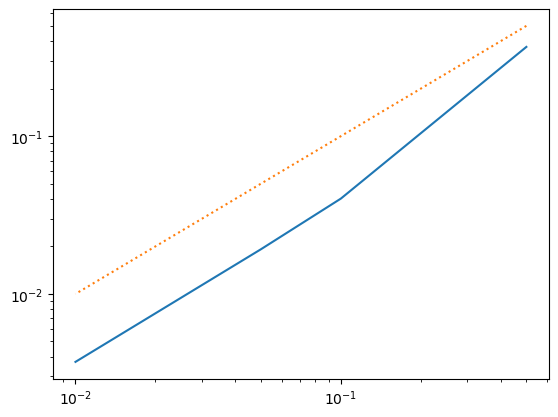

In [26]:
err=[]

for h in [0.5,0.1, 0.05, 0.01]:
    tEA, yEA = eulero_avanti(f, t0, t_max, [y0], h)
    err.append( np.max(np.abs(yEA[:, 0] - yex(tEA))))
    
plt.loglog([0.5, 0.1, 0.05, 0.01], err)
plt.loglog([0.5, 0.1, 0.05, 0.01], [0.5, 0.1, 0.05, 0.01], ':')


Confrontando l'errore con l'andamento lineare verifichiamo che il metodo è del primo ordine come previsto dalla teoria.

#### **(3e) (1 punto - extra) [T]**

Illustrare quali metodi possono essere utilizzati per ottenere un ordine di convergenza superiore a 1.

##### **Soluzione.** 



Fra i metodi lineari a un passo solo il metodo di Crank Nicholson garantisce un ordine di convergenza pari a 2. In alternativa, per ottenere metodi di alto ordine, ci sono due possibilità:
- usare metodi *mutistep* che usano il valore della soluzione nel passo $n$, $n+1$ e in altri tempi precedenti ($n-1$, $n-2$ eccetera).
- usare metodi di Runge-Kutta, che sono nonlineari.